# Midterm Exam (part 3) - Computational Physics I

### Deadline: Monday 7 April 2024 (by 19h00)
### Name: Juan Daniel Vasconez

## Part 3. (12 points) Data analysis and visualisation (Rayleigh-Taylor instability)

The **Rayleigh-Taylor instability** occurs at the interface between two fluids of different densities when the lighter fluid is pushing the heavier fluid. Examples include the behavior of water suspended above oil in the gravity of Earth, mushroom clouds like those from volcanic eruptions and atmospheric nuclear explosions, supernova explosions in which expanding core gas is accelerated into denser shell gas.

In this problem, you will analyse a simulation of the Rayleigh-Taylor instability arising at the interface between 2 gases (one heavy and one light) in 2D. The initial condition consists of an interface separating two gases with different densities in hydrostatic balance:

$$
\rho(y) = \begin{cases}
1 & \text{for } y \le 0 \\
\eta & \text{for } y > 0
\end{cases}
\,,\qquad
p = p_0 + \rho\,y\,g
$$

where $\eta$ is the density of the gas on top in code units, $g$ is the (constant) gravity pointing in the negative $y$ direction. The system is destabilized by perturbing the vertical velocity in proximity of the interface using a single mode perturbation. The computational domain has **periodic boundary conditions** along the $X-$axis and and **reflective boundary conditions** along the $Y-$axis. The dimensions of the Cartesian domain are: $x\in[-0.5,0.5]$ and $y\in[-1.0,1.0]$ in code units.


The mono-atomic gas has an adiabatic index $\gamma=\frac{5}{3}$, and the numerical simulation produces $101$ VTK files stored in the **Rayleigh-Taylor** zipped folder: 

https://www.dropbox.com/scl/fi/j43rixdhy9upkgt76t2kl/Rayleigh_Taylor.zip?rlkey=jgliqdj4p94igr2xxna05iyax&st=h59onv8c&dl=0

which also contains the following descriptor files:

- a **units.out** file that contains the CGS normalisation values.
- a **vtk.out** file whose second column contains the times in code units.
- a **grid.out** file that contains information on the grid structure.

You can use VisIt to inspect the data. The written fields are: 

- density (rho)
- thermal pressure (prs)
- velocity_x (vx1)
- velocity_y (vx2)
- tracer (tr1), which is a pigment tracing the heavier gas on top.

**References:**

https://en.wikipedia.org/wiki/Rayleigh%E2%80%93Taylor_instability

https://iopscience.iop.org/article/10.1086/523099


In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
import pandas as pd
import os
import cv2 as cv2


### Part A: I/O and visualisation

Within a single python notebook, carry out the following tasks:

(a) Create a python function that reads the **units.out** file, stores the normalisation values for length, velocity, and density, calculates the normalisation values for thermal pressure and time, and returns them all into tuple objects.

**Note:**
As shown in class, the normalisation values for thermal pressure ($p_0=\rho_0\,v_0^2$) and time ($t_0=\frac{L_0}{v_0}$) can be derived from the length, velocity, and density values.


In [2]:
fname = './Rayleigh_Taylor/Rayleigh_Taylor'

In [ ]:
def units_data(fname):
    """
    Function to load and calculate normalization values from 'units.out'.
    """
    # Read the 'units.out' file
    df_units = pd.read_csv(fname + '/units.out', sep=',')

    # Extract normalization values into a list of tuples
    units = [(row['variable'], row['normalisation']) for _, row in df_units.iterrows()]

    # Calculate thermal pressure normalization
    pre_0 = units[0][1] * units[1][1]**2
    units.append(('pre_0', pre_0))

    # Calculate time normalization
    time_0 = units[2][1] / units[1][1]
    units.append(('time_0', time_0))

    # Return all normalization values
    return units

# Retrieve normalization values
units_cgs = units_data(fname)

# Print normalization values
print(units_cgs)


[('rho_0', 1.673e-24), ('v_0', 100000.0), ('L_0', 14960000000000.0), ('pre_0', 1.673e-14), ('time_0', 149600000.0)]



(b) Create a python function that reads the **vtk.out** file, reads the second column, and returns the times in CGS units using $t_0$ from point (a).


In [ ]:
def time_vtk(fname, units):
    """
    This function loads the time data from the file
    and returns it as a numpy array in CGS units.
    """
    # Read the 'vtk.out' file
    df_time = pd.read_csv(fname + '/vtk.out', sep=r'\s+', header=None)
    
    # Extract the second column (time data) and convert to numpy array
    time = np.array(df_time.iloc[:, 1], dtype=float)
    
    # Convert time to CGS units using the normalization factor
    time = time * units[4][1]  

    return time

# Get the time data in CGS units
time_cgs = time_vtk(fname, units_cgs)

# Print the time array
print('Time:', time_cgs)


Time: [0.00000000e+00 2.83058459e+07 5.64427486e+07 8.50125038e+07
 1.13582274e+08 1.42093925e+08 1.70132450e+08 1.98646510e+08
 2.27166553e+08 2.55703650e+08 2.84236260e+08 3.12347297e+08
 3.40890378e+08 3.69432712e+08 3.97553622e+08 4.26095956e+08
 4.54644124e+08 4.83187505e+08 5.11312604e+08 5.39871693e+08
 5.68426294e+08 5.96562912e+08 6.25151771e+08 6.53652217e+08
 6.81752482e+08 7.10290777e+08 7.38828772e+08 7.67375444e+08
 7.95476009e+08 8.24023578e+08 8.52564117e+08 8.81114080e+08
 9.09166773e+08 9.37677092e+08 9.66221520e+08 9.94772530e+08
 1.02288491e+09 1.05141453e+09 1.07994250e+09 1.10847332e+09
 1.13658869e+09 1.16511547e+09 1.19365122e+09 1.22219340e+09
 1.25031461e+09 1.27886832e+09 1.30743474e+09 1.33556851e+09
 1.36413837e+09 1.39263762e+09 1.42105040e+09 1.44927693e+09
 1.47765231e+09 1.50626256e+09 1.53451452e+09 1.56317190e+09
 1.59164078e+09 1.61994958e+09 1.64850972e+09 1.67682152e+09
 1.70525749e+09 1.73386101e+09 1.76221320e+09 1.79040532e+09
 1.81897892e+09 1.


(c) Create a python function that reads a VTK data file, normalises the data fields to CGS units using the values from points (a) and (b), and returns them jointly with the mesh and time information as tuple objects. Note that the tracer is dimensionless, so it does not require normalisation.


In [ ]:
def vtk_data(fname, file_number):
    """
    This function loads the vtk data from the file
    and returns it as a numpy array
    """
    
    # Retrieve normalization units and time data
    units = units_data(fname)
    time = time_vtk(fname, units)
    
    # Read the VTK file
    mesh = pv.read(fname + f'/data.{file_number:04d}.vtk')
    
    # Extract and normalize data fields
    rho = pv.get_array(mesh, 'rho', preference='cell') * units[0][1]
    vx1 = pv.get_array(mesh, 'vx1', preference='cell') * units[1][1]
    vx2 = pv.get_array(mesh, 'vx2', preference='cell') * units[1][1]
    prs = pv.get_array(mesh, 'prs', preference='cell') * units[3][1]
    tr1 = pv.get_array(mesh, 'tr1', preference='cell')  # Tracer is dimensionless
    
    # Reshape data to 2D arrays based on mesh dimensions
    dimensions = mesh.GetDimensions()
    rho_cgs2D = rho.reshape(dimensions[1] - 1, dimensions[0] - 1)
    vx1_cgs2D = vx1.reshape(dimensions[1] - 1, dimensions[0] - 1)
    vx2_cgs2D = vx2.reshape(dimensions[1] - 1, dimensions[0] - 1)
    prs_cgs2D = prs.reshape(dimensions[1] - 1, dimensions[0] - 1)
    tr1_cgs2D = tr1.reshape(dimensions[1] - 1, dimensions[0] - 1)
    
    # Create 2D mesh grid for coordinates
    x = np.linspace(mesh.bounds[0], mesh.bounds[1], dimensions[0] - 1) * units[2][1]
    y = np.linspace(mesh.bounds[2], mesh.bounds[3], dimensions[1] - 1) * units[2][1]
    x2D, y2D = np.meshgrid(x, y)
    
    # Pack data and mesh into tuples
    data = (rho_cgs2D, vx1_cgs2D, vx2_cgs2D, prs_cgs2D, tr1_cgs2D)
    mesh = (x2D, y2D)
    vtk_data = (mesh, data, time)
   
    return vtk_data

# Load VTK data for file number 75
vtk_result = vtk_data(fname, 75)

(dx2) Call all the above functions for VTK file **# 75** of each simulation, and make the following maps using the correct mesh coordinates, dimensions and time, all in in CGS units:

- A figure showing the gas density, $\rho$.

- A figure showing the gas sound speed, $c_s=\sqrt{\gamma\frac{p}{\rho}}$.

- A figure showing showing the kinetic energy density, $E_k = \frac{1}{2}\rho\,v^2$ with $v=\sqrt{v_x^2+v_y^2}$.

- A figure showing the tracer, $h_{gas}\equiv \rm tr1$, of the heavier gas.

**Notes:** Choose different perceptually-uniform colour schemes for each of the above quantities, and fix the colour bar limits. Add the correct time stamp in CGS units to each map. Since these are high-resolution models, one way to improve the visualisation of 2D vector fields is to interpolate them into a coarser grid.

In [18]:
# Unpack the vtk_result tuple
mesh_75, data_75, time = vtk_result

# Unpack the data tuple
rho_75, vx1_75, vx2_75, prs_75, tr_75 = data_75

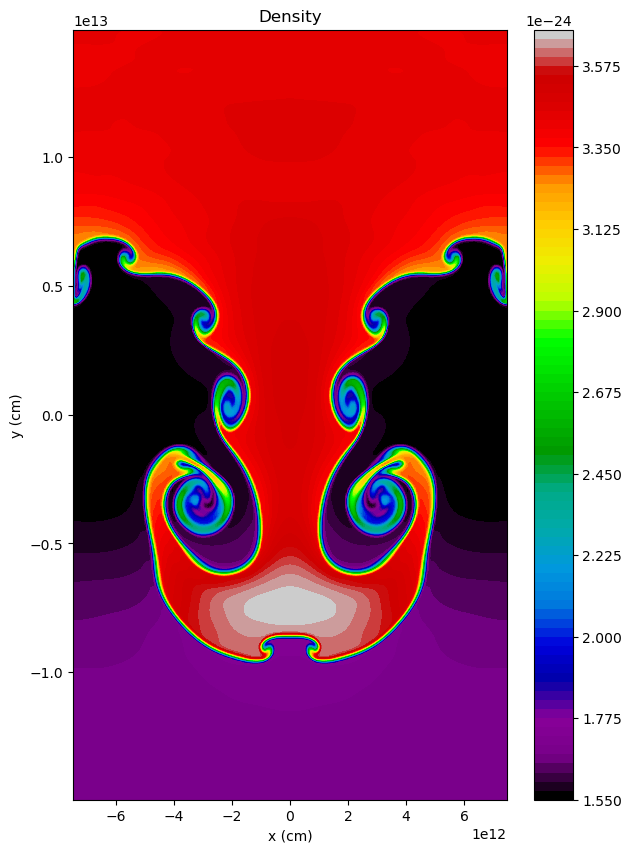

In [19]:
# Define color bar limits for density
vmin = rho_75.min()
vmax = rho_75.max()

# Plot the Density
plt.figure(figsize=(7, 10))
z = plt.contourf(mesh_75[0], mesh_75[1], rho_75, levels=100, cmap='nipy_spectral', vmin=vmin, vmax=vmax)
plt.colorbar(z)
plt.title('Density')
plt.xlabel('x (cm)')
plt.ylabel('y (cm)')
plt.show()

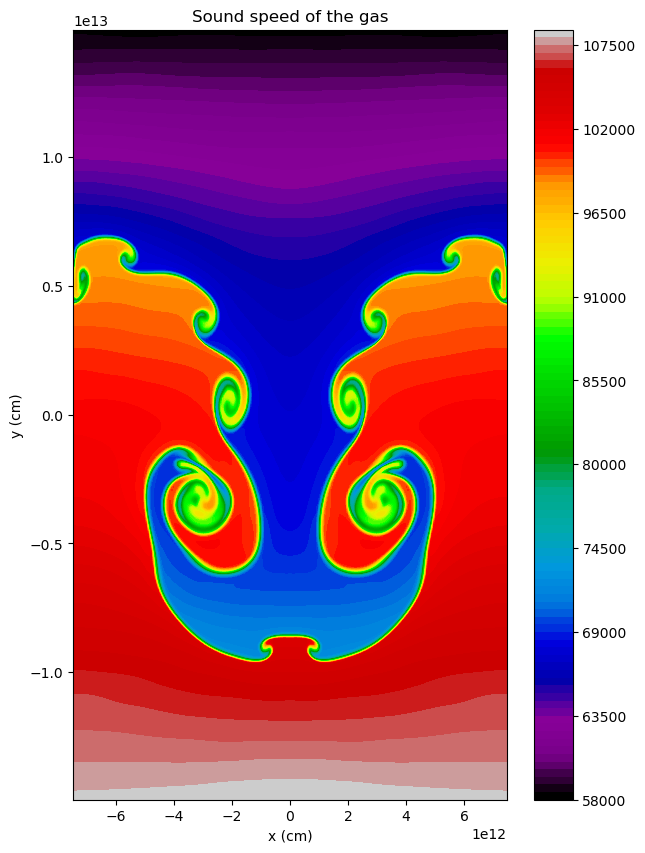

In [20]:
# Calculate the sound speed and plot it
c_S = np.sqrt(5/3 * (prs_75 / rho_75))

# Define color bar limits for sound speed
vmin = c_S.min()
vmax = c_S.max()

plt.figure(figsize=(7, 10))
z = plt.contourf(mesh_75[0], mesh_75[1], c_S, levels=100, cmap='nipy_spectral', vmin=vmin, vmax=vmax)
plt.colorbar(z)
plt.title('Sound speed of the gas')
plt.xlabel('x (cm)')
plt.ylabel('y (cm)')
plt.show()


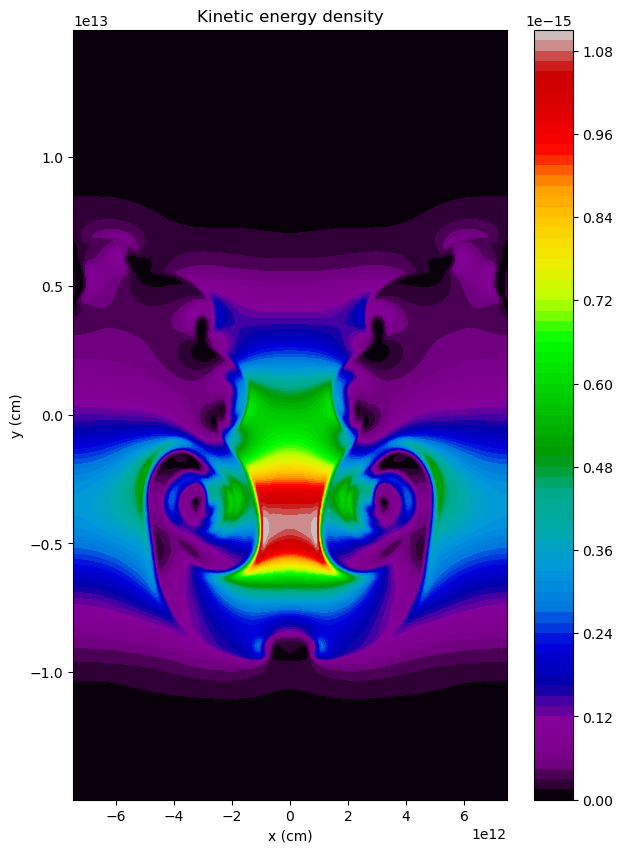

In [21]:
# Calculate the kinetic energy density and plot it
E_k = 0.5 * rho_75 * (vx1_75**2 + vx2_75**2)

# Define color bar limits for kinetic energy density
vmin = E_k.min()
vmax = E_k.max()

plt.figure(figsize=(7, 10))
z = plt.contourf(mesh_75[0], mesh_75[1], E_k, levels=100, cmap='nipy_spectral', vmin=vmin, vmax=vmax)
plt.colorbar(z)
plt.title('Kinetic energy density')
plt.xlabel('x (cm)')
plt.ylabel('y (cm)')
plt.show()

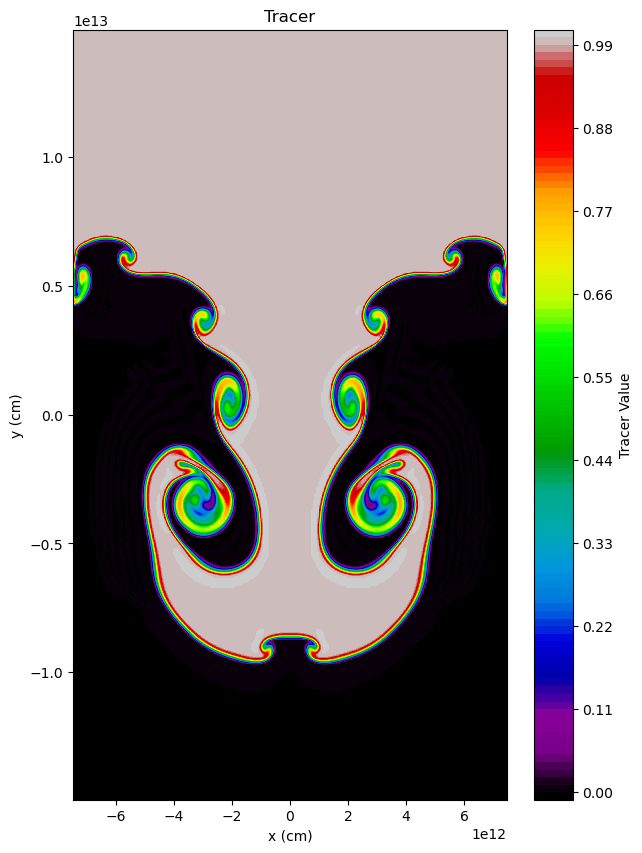

In [22]:
# Plot the tracer
plt.figure(figsize=(7, 10))
z = plt.contourf(mesh_75[0], mesh_75[1], tr_75, levels=100, cmap='nipy_spectral', vmin=0, vmax=1)
cbar = plt.colorbar(z)
cbar.set_label('Tracer Value')
plt.title('Tracer')
plt.xlabel('x (cm)')
plt.ylabel('y (cm)')
plt.show()



### Part B: Analysis of the density field

(e) Create a set of Python functions that loop over all the VTK simulation files and returns maps of the density field $\rho$, the kinetic energy density $E_k$, and also histograms of the density field in CGS units for all times, into a folder called **"output_data"**.


In [33]:
def output(fname, target):
    """
    This function loops over all the vtk files and
    returns the maps of the density fields, the kinetic
    energy density, and histograms of the density field
    in CGS units into the target folder.
    """
    # Create the output directory if it doesn't exist
    os.makedirs(target, exist_ok=True)
    
    # Loop over all 101 VTK files (from 0 to 100)
    for i in range(101):
        try:
            vtk_result = vtk_data(fname, i)
            mesh, data, time = vtk_result
            rho, vx1, vx2, prs, tr = data
            
            # Save the density field
            plt.figure(figsize=(7, 10))
            z = plt.contourf(mesh[0], mesh[1], rho, levels=100, cmap='nipy_spectral', vmin=rho.min(), vmax=rho.max())
            plt.colorbar(z)
            plt.title(f'Density at time {time[i]:.2e} s')
            plt.xlabel('x (cm)')
            plt.ylabel('y (cm)')
            plt.savefig(f'{target}/density_{i:04d}.png')
            plt.close()
            
            # Calculate and save the kinetic energy density
            E_k = 0.5 * rho * (vx1**2 + vx2**2)
            plt.figure(figsize=(7, 10))
            z = plt.contourf(mesh[0], mesh[1], E_k, levels=100, cmap='nipy_spectral', vmin=E_k.min(), vmax=E_k.max())
            plt.colorbar(z)
            plt.title(f'Kinetic Energy Density at time {time[i]:.2e} s')
            plt.xlabel('x (cm)')
            plt.ylabel('y (cm)')
            plt.savefig(f'{target}/kinetic_energy_{i:04d}.png')
            plt.close()
            
            # Save the histogram of the density field
            plt.figure(figsize=(7, 10))
            plt.hist(rho.flatten(), bins=100, density=True, alpha=0.7, color='blue')
            plt.title(f'Density Histogram at time {time[i]:.2e} s')
            plt.xlabel('Density (g/cm^3)')
            plt.ylabel('Frequency')
            plt.savefig(f'{target}/density_histogram_{i:04d}.png')
            plt.close()
        
        except Exception as e:
            print(f"Error processing file {i}: {e}")
    
    return None

fname = './Rayleigh_Taylor/Rayleigh_Taylor'
target = './Rayleigh_Taylor/Rayleigh_Taylor/output_data'

output(fname, target)



(f) Briefly describe: what happens with the density field as time progresses? Does the density field follow any statistical distribution at late times?


As time progresses in cosmological simulations, the density field undergoes significant evolution:

Initially, the density field starts nearly uniform with small fluctuations.
Over time, gravitational instability causes overdense regions to grow denser while underdense regions become more depleted.
This leads to the formation of the cosmic web structure with dense clusters, filaments, sheets, and voids.
At late times, the density distribution becomes distinctly non-Gaussian and multi-modal.

At late times, the density field doesn't follow a single clean statistical distribution. Instead, it exhibits characteristics of a mixture distribution with multiple peaks representing different cosmic structures. While the overall distribution has some log-normal characteristics (especially in moderately overdense regions), significant deviations occur at both the high-density (collapsed structures) and low-density (voids) extremes.
This multi-modality reflects the physical reality that matter has segregated into distinct environments through non-linear gravitational evolution.


### Part C: Time evolution and derivatives

(gx2) Create a set of Python functions that loops over all the VTK simulation files, computes the following quantities in CGS units for each time:

- the average gas temperature, $\overline T$, (**Hint:** the temperature in each grid cell can be calculated using the equation of state for ideal gases, i.e., $p=\frac{\rho\,k_B\,T}{\mu\,m_u}$, where $k_B$ is the Boltzmann constant, $m_u$ is the atomic mass unit, and $\mu=0.6$ is the mean particle mass in the gas.)

- the average kinetic energy density of the gas, $\overline E_k$, where $E_k = \frac{1}{2}\rho\,v^2$.

- the rate of change of average kinetic energy density, $\dot{\overline E_k}$.

- the average sound speed of the heavier gas, $\overline c_{s,h}$, where $c_{s,h}=h_{gas}\,\sqrt{\gamma\,\frac{p}{\rho}}$

and returns:

- a CSV file with 5 columns, time on the first column, and the above quantities in the next ones. The CSV file should be named **"stats.csv"** saved into the folder called **"output_data"**.



(h) Create a Python function that reads in the CSV file created in (g) and returns (i.e. shows or saves) high-quality labeled figures of each of the above-computed quantities versus time, into the folder called **"output_data"**. 


In [29]:
def output_data(fname, target):
    """
    This function loops over all the vtk files and
    returns a csv, with the average gas temperature,
    the average kinetic energy density, the average
    rate of change of the average kinetic energy density
    and the average sound speed of the heavier gas.
    """
    # Create the output directory if it doesn't exist
    os.makedirs(target, exist_ok=True)
    kb = 1.3807e-16
    mu = 1.6605e-24
    mui = 0.6
    
    # Initialize lists to store all time steps data
    all_times = []
    all_E_k_avg = []
    
    # First loop: collect times and kinetic energy averages
    for i in range(101):
        try:
            vtk_result = vtk_data(fname, i)
            _, data, time = vtk_result
            rho, vx1, vx2, prs, tr = data
            
            # Calculate kinetic energy density
            E_k = 0.5 * rho * (vx1**2 + vx2**2)
            E_k_avg = np.mean(E_k)
            
            # Store data for gradient calculation later
            all_times.append(time[i])
            all_E_k_avg.append(E_k_avg)
            
        except Exception as e:
            print(f"Error processing file {i}: {e}")
    
    # Now loop again to calculate everything including the gradient
    for i in range(101):
        try:
            vtk_result = vtk_data(fname, i)
            _, data, time = vtk_result
            rho, vx1, vx2, prs, tr = data
            
            # Calculate the average gas temperature
            T = (prs * mui * mu) / (rho * kb)
            T_avg = np.mean(T)
            
            # Calculate the average kinetic energy density
            E_k = 0.5 * rho * (vx1**2 + vx2**2)
            E_k_avg = np.mean(E_k)
            
            # Calculate gradient using all time steps data
            E_k_avg_rate = np.gradient(all_E_k_avg, all_times)[i]
            
            # Calculate the average sound speed of the heavier gas
            c_S = tr * np.sqrt(5/3 * (prs / rho))  # Using tracer for heavy gas
            c_S_avg = np.mean(c_S)
            
            # Create a DataFrame to store the results
            results = pd.DataFrame({
                'time': [time[i]],
                'T_avg': [T_avg],
                'E_k_avg': [E_k_avg],
                'E_k_avg_rate': [E_k_avg_rate],
                'c_S_avg': [c_S_avg]
            })
            
            # Append the results to the CSV file
            csv_path = f'{target}/stats.csv'
            if not os.path.exists(csv_path):
                results.to_csv(csv_path, index=False)
            else:
                results.to_csv(csv_path, mode='a', header=False, index=False)
                
        except Exception as e:
            print(f"Error processing file {i}: {e}")
            
    return None

fname = './Rayleigh_Taylor/Rayleigh_Taylor'
target = './Rayleigh_Taylor/Rayleigh_Taylor/output_data'
output_data(fname, target)


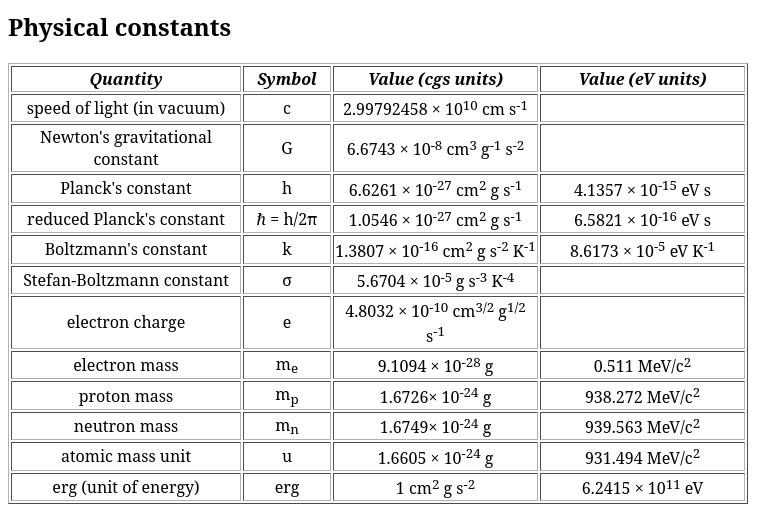

Reference for constants: https://www.physics.rutgers.edu/~abrooks/342/constants.html

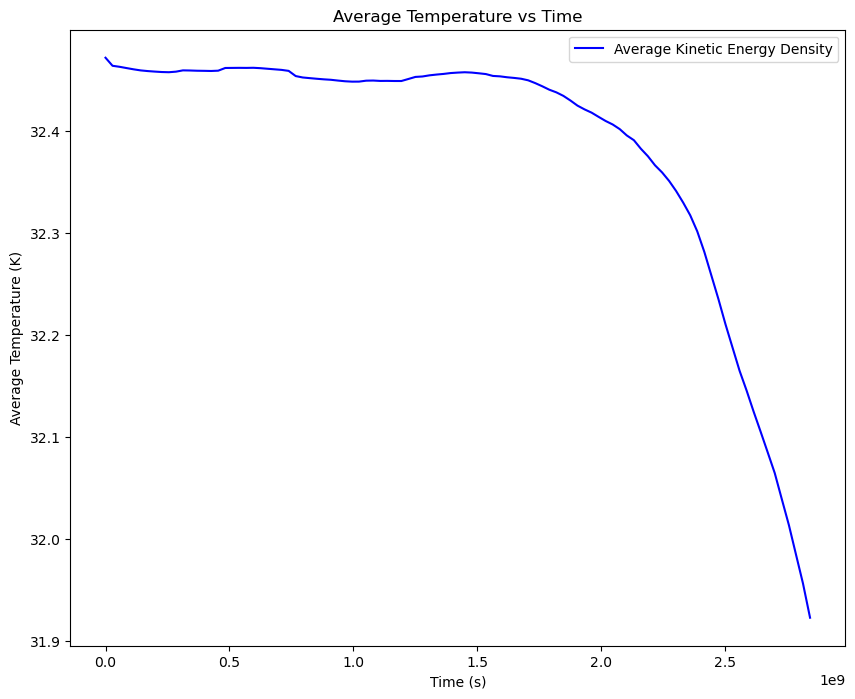

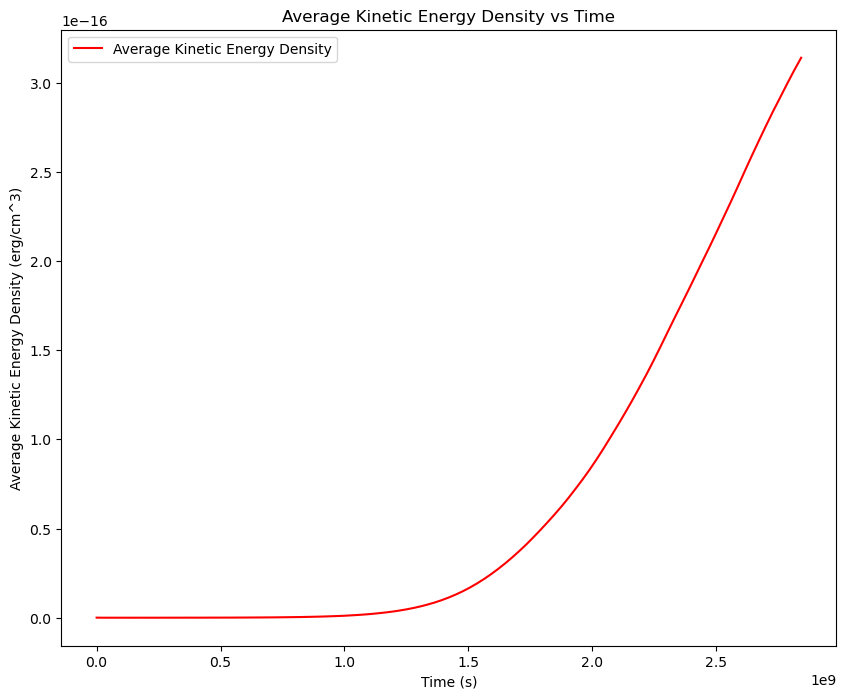

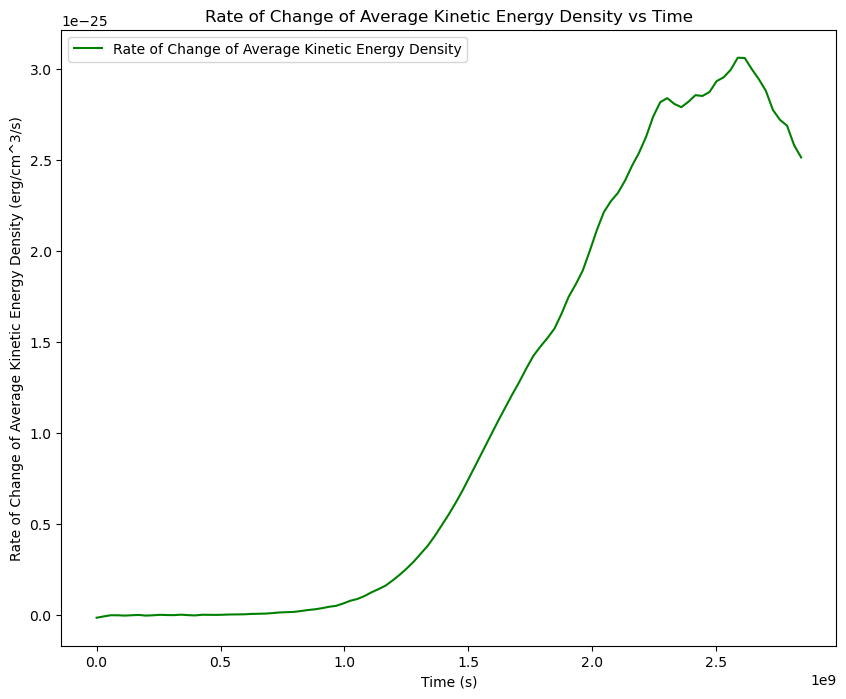

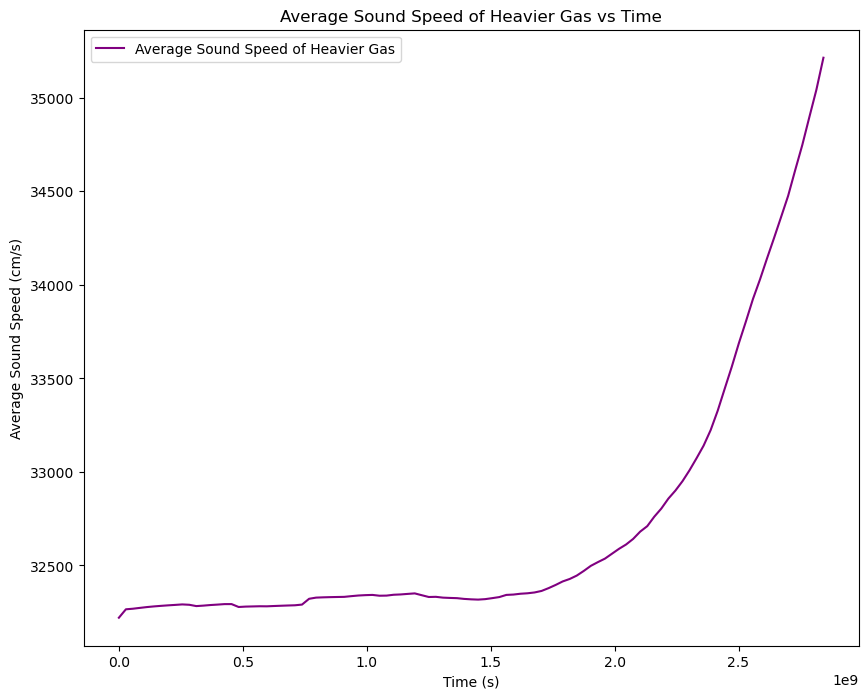

In [30]:
def plotting(fname):
    """
    This function plots the average kinetic energy density
    and the average sound speed of the heavier gas.
    """
    df = pd.read_csv(fname + '/output_data/stats.csv')

    # Plot the average temperature
    plt.figure(figsize=(10, 8))
    plt.plot(df['time'], df['T_avg'], label='Average Kinetic Energy Density', color='blue')
    plt.xlabel('Time (s)')
    plt.ylabel('Average Temperature (K)')
    plt.title('Average Temperature vs Time')
    plt.legend()
    plt.savefig(fname + '/output_data/average_Temp.png')
    plt.show()
    plt.close()
    
    # Plot the average kinetic energy density
    plt.figure(figsize=(10, 8))
    plt.plot(df['time'], df['E_k_avg'], label='Average Kinetic Energy Density', color='red')
    plt.xlabel('Time (s)')
    plt.ylabel('Average Kinetic Energy Density (erg/cm^3)')
    plt.title('Average Kinetic Energy Density vs Time')
    plt.legend()
    plt.savefig(fname + '/output_data/average_E_k.png')
    plt.show()
    plt.close()
    
    # Plot the average rate of change of kinetic en energy
    plt.figure(figsize=(10, 8))
    plt.plot(df['time'], df['E_k_avg_rate'], label='Rate of Change of Average Kinetic Energy Density', color='green')
    plt.xlabel('Time (s)')
    plt.ylabel('Rate of Change of Average Kinetic Energy Density (erg/cm^3/s)')
    plt.title('Rate of Change of Average Kinetic Energy Density vs Time')
    plt.legend()
    plt.savefig(fname + '/output_data/average_E_k_rate.png')
    plt.show()
    plt.close()
    
    # Plot the average sound speed of the heavier gas
    plt.figure(figsize=(10, 8))
    plt.plot(df['time'], df['c_S_avg'], label='Average Sound Speed of Heavier Gas', color='purple')
    plt.xlabel('Time (s)')
    plt.ylabel('Average Sound Speed (cm/s)')
    plt.title('Average Sound Speed of Heavier Gas vs Time')
    plt.legend()
    plt.savefig(fname + '/output_data/average_c_S.png')
    plt.show()
    plt.close()
    
    return None
fname = './Rayleigh_Taylor/Rayleigh_Taylor'

plotting(fname)        


### Part D: Animations and steady state

(i) Briefly describe: What happens to the average kinetic energy, its derivative, and the average sound speed of the heavier gas as time progresses? Does the flow reach steady state? 



(j) Create a Python function that returns movies showing the time evolution of the kinetic energy density maps computed in (d) and their average values and rates of change calculated in (g). The movies should be saved into the folder called **"output_data"**. 

#### Average Kinetic Energy Density :

- Remains nearly constant and close to zero until $~1.0×10^9$ seconds
- Begins to increase gradually around $1.2×10^9$ seconds
- Shows accelerating growth after $1.5×10^9$ seconds
- Continues increasing exponentially through the end of the simulation


#### Rate of Change of Average Kinetic Energy Density :

- Nearly zero until $~1.0×10^9$ seconds
- Begins increasing after $1.0×10^9$ seconds
- Shows rapid acceleration between $1.5-2.0×10^9$ seconds
- Reaches a peak around $2.5×10^9$ seconds
- Begins decreasing near the end of the simulation


#### Average Sound Speed of Heavier Gas :

- Starts at ~32,300 cm/s and remains relatively stable until $~1.5×10^9$ seconds
- Shows gradual increase until $~2.0×10^9$ seconds
- Exhibits rapid acceleration after $2.0×10^9$ seconds
- Continues increasing sharply through the end of the simulation


#### Average Temperature:

- Shows a slight declining trend initially
- Begins decreasing more noticeably after $2.0×10^9$ seconds
- Decreases rapidly near the end of the simulation



The flow does not reach steady state. Instead, it shows evidence of a dynamical system that's evolving with increasing energy and velocity while cooling. The decreasing rate of change of kinetic energy density near the end might suggest an approach toward some different state, but the continuing increases in sound speed and kinetic energy density indicate the system remains in a transient phase throughout the simulation period.

In [34]:
def sort_images_into_folders(source_folder):
    """
    Sort images into separate folders based on their prefixes.
    """
    # Define the prefixes and corresponding target folders
    prefixes = ['density_histogram', 'density', 'kinetic_energy']
    target_folders = {prefix: os.path.join(source_folder, prefix) for prefix in prefixes}

    # Create target folders if they don't exist
    for folder in target_folders.values():
        os.makedirs(folder, exist_ok=True)

    # Iterate through the images in the source folder
    for img in os.listdir(source_folder):
        if img.endswith((".jpg", ".jpeg", ".png")):
            for prefix in prefixes:
                if img.startswith(prefix):
                    # Move the image to the corresponding folder
                    src_path = os.path.join(source_folder, img)
                    dest_path = os.path.join(target_folders[prefix], img)
                    os.rename(src_path, dest_path)
                    break

    print("Images sorted into folders:", target_folders)

# Source folder containing the images
source_folder = './Rayleigh_Taylor/Rayleigh_Taylor/output_data'

# Call the function to sort images
sort_images_into_folders(source_folder)

Images sorted into folders: {'density_histogram': './Rayleigh_Taylor/Rayleigh_Taylor/output_data/density_histogram', 'density': './Rayleigh_Taylor/Rayleigh_Taylor/output_data/density', 'kinetic_energy': './Rayleigh_Taylor/Rayleigh_Taylor/output_data/kinetic_energy'}


In [35]:
img_den = './Rayleigh_Taylor/Rayleigh_Taylor/output_data/density'
img_kin = './Rayleigh_Taylor/Rayleigh_Taylor/output_data/kinetic_energy'
img_hist = './Rayleigh_Taylor/Rayleigh_Taylor/output_data/density_histogram'

def create_video_from_images(folder, output_filename='created_video.mp4', fps=5):
    images = [img for img in os.listdir(folder) if img.endswith((".jpg", ".jpeg", ".png"))]
    images.sort()  # Sort the images to maintain order

    if not images:
        print("No images found in the folder.")
        return

    first_image = cv2.imread(os.path.join(folder, images[0]))
    h, w, _ = first_image.shape

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    video_writer = cv2.VideoWriter(output_filename, fourcc, fps, (w, h))

    for image in images:
        img_path = os.path.join(folder, image)
        frame = cv2.imread(img_path)
        video_writer.write(frame)

    video_writer.release()
    print(f"Video saved as {output_filename}")

# Define the output path
output_path = './Rayleigh_Taylor/Rayleigh_Taylor/output_data/videos'
os.makedirs(output_path, exist_ok=True)

# Create videos from the images in the specified folders
create_video_from_images(img_den, output_filename=f'{output_path}/density_video.mp4')
create_video_from_images(img_kin, output_filename=f'{output_path}/kinetic_energy_video.mp4')
create_video_from_images(img_hist, output_filename=f'{output_path}/density_histogram_video.mp4')


Video saved as ./Rayleigh_Taylor/Rayleigh_Taylor/output_data/videos/density_video.mp4
Video saved as ./Rayleigh_Taylor/Rayleigh_Taylor/output_data/videos/kinetic_energy_video.mp4
Video saved as ./Rayleigh_Taylor/Rayleigh_Taylor/output_data/videos/density_histogram_video.mp4
